# Import libraries

In [22]:
from pathlib import Path
import os

# Get current directory
current_dir = os.getcwd() 

# Navigate up from notebooks/ to project root
PROJECT_ROOT = Path(current_dir).resolve().parent

# File paths
DATA_PATH = PROJECT_ROOT
MODEL_PATH = PROJECT_ROOT
SCALER_PATH = PROJECT_ROOT

In [23]:
!pip install xgboost

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE 
from scipy.stats import randint, uniform, loguniform
from tabulate import tabulate
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import joblib # To export models

# Setup

In [26]:
# Load data
df = pd.read_csv(DATA_PATH / "Combined_Dataset_Final.csv")
print(len(df))

3120


In [27]:
# Create unique season identifier 
df["team_season"] = df["team_name"] + " " + df["season"]

# Map certain teams to their known styles
team_style_map = {
    # Elite Hybrids (They do both at a world-class level)
    'Barcelona 2015/2016': ['Possession', 'High Pressing'],
    'Bayern Munich 2015/2016': ['Possession', 'High Pressing'],
    'Paris Saint-Germain 2015/2016': ['Possession', 'High Pressing'],
    
    # Pure Possession (Build out of the back, but drop into a mid-block to defend)
    'Arsenal 2015/2016': ['Possession'],
    'Fiorentina 2015/2016': ['Possession'],
    'Spain 2018': ['Possession'],
    
    # Pure High Pressing (Heavy metal pressing, but direct/transitional with the ball)
    'Bayer Leverkusen 2015/2016': ['High Pressing'],
    'Borussia Dortmund 2015/2016': ['High Pressing'],
    'Eibar 2015/2016': ['High Pressing'],
    
    # Counter Attack (Deep block, low possession)
    'Leicester City 2015/2016': ['Counter Attack'],
    'Atlético Madrid 2015/2016': ['Counter Attack'],
    'Crystal Palace 2015/2016': ['Counter Attack'],        # Alan Pardew (Zaha/Bolasie pure wing counters)
    'Sunderland 2015/2016': ['Counter Attack'],            # Sam Allardyce (Survival football)
    'Darmstadt 98 2015/2016': ['Counter Attack'],          # Dirk Schuster (Averaged 30% possession)
    'France 2018': ['Counter Attack']                      # Deschamps (Won the World Cup with 40% possession)
}

In [28]:
# Apply the mapping
df['style_label'] = df['team_season'].map(team_style_map)
df = df.dropna(subset=['style_label'])
print(len(df))

234


# Preprocessing

In [30]:
# Define positions
def categorise_positions(pos):
    if 'Goalkeeper' in pos: return 'GK'
    if 'Back' in pos: return 'Defender'
    if 'Midfield' in pos: return 'Midfielder'
    if 'Wing' in pos or 'Forward' in pos: return 'Attacker'
    return 'Other'

df['position_group'] = df['primary_position'].apply(categorise_positions)

# Filter out goalkeepers
df = df[df['position_group'] != 'GK']

In [31]:
# Check for dataset balance#

# Drop playrs without a label
labeled_df = df.dropna(subset=["style_label"]).copy()

# Explode the lists so Pandas can count them
exploded_df = labeled_df.explode("style_label")

# Check for dataset balance
print("Overall Style Distribution:")
print(exploded_df["style_label"].value_counts())

print("\nStyle Distribution by Position")
print(pd.crosstab(exploded_df['position_group'], exploded_df['style_label']))

Overall Style Distribution:
style_label
Counter Attack    89
Possession        88
High Pressing     81
Name: count, dtype: int64

Style Distribution by Position
style_label     Counter Attack  High Pressing  Possession
position_group                                           
Attacker                    24             20          27
Defender                    32             36          36
Midfielder                  33             25          25


In [32]:
# Select features based on positions
defender_features = [
    # Possession / Build-up
    "total_passes_per90",           # Crucial: Possession CBs touch the ball 80+ times a game
    "pass_completion_pct", 
    "passes_into_final_third_per90", 
    "progressive_carries_per90", 
    
    # Defensive Actions & Line Height
    "avg_defensive_distance",       # The single most important stat for identifying a High Line
    "total_pressures_per90", 
    "counterpressures_per90", 
    
    # Counter Attacking (Transition)
    "successful_long_passes_per90", # Booting it clear or hitting the wingers
    "pass_directness_ratio"         # Low block defenders only pass forward, rarely sideways
]

midfielder_features = [
    # Possession Metronomes
    "total_passes_per90",
    "pass_completion_pct", 
    "passes_into_final_third_per90", 
    "pressure_receipt_pct",         # Elite possession mids rarely lose the ball under pressure
    "progressive_carries_per90", 
    
    # Pressing Engines
    "total_pressures_per90", 
    "final_third_pressures_per90", 
    "counterpressures_per90", 
    "high_ball_recoveries_per90", 
    
    # Transition Drivers
    "explosive_carries_per90",      # Driving through the midfield on a counter
    "pass_directness_ratio",
    "successful_long_passes_per90"
]

attacker_features = [
    # Possession / Box Threat
    "touches_in_box_per90",         # Possession attackers practically live in the penalty box
    "pass_completion_pct",
    "pressure_receipt_pct",
    
    # High Pressing Forwards
    "final_third_pressures_per90",  # The gold standard for pressing forwards
    "counterpressures_per90", 
    "high_ball_recoveries_per90", 
    
    # Counter Attacking & Target Men
    "explosive_carries_per90", 
    "avg_shot_quality",             # Counter attackers take fewer, but higher xG (1-on-1) shots
    "aerial_duels_won_per90",       # Target men flicking the ball on for the counter
    "avg_receipt_distance_from_goal" # Counter attackers receive the ball 50+ yards from goal
]

# Model Training and Comparison

In [34]:
# Define positions and styles for training
position_groups = ['Defender', 'Midfielder', 'Attacker']
target_styles = ["Possession", "High Pressing", "Counter Attack"]

In [35]:
# Define data variables for a results table
defender_possession = 0
defender_pressing = 0
defender_counter = 0

midfielder_possession = 0
midfielder_pressing = 0
midfielder_counter = 0

attacker_possession = 0
attacker_pressing = 0
attacker_counter = 0

defender_average = 0
midfielder_average = 0
attacker_average = 0

possession_average = 0
pressing_average = 0
counter_average = 0

overall_average = 0

In [36]:
# Function to train, tune and test a model
def training(model, param_dist):
    # Define variables to store best models
    df_poss_model = None
    df_press_model = None
    df_counter_model = None

    mf_poss_model = None
    mf_press_model = None
    mf_counter_model = None

    att_poss_model = None
    att_press_model = None
    att_counter_model = None
    
    for group in position_groups:
        print("------------")
        print(f"{group.upper()}S")
        print("------------")
    
        # Subset data
        group_data = df[df["position_group"] == group].copy()
    
        # Features to train model on
        if group == "Defender":
            X = group_data[defender_features]
        if group == "Midfielder":
            X = group_data[midfielder_features]
        if group == "Attacker":
            X = group_data[attacker_features]
        
        # Train 1 model for each style
        for target_style in target_styles:
            print(f"MODEL FIT FOR {target_style.upper()}\n")
    
            # Create binary label (1 = fit, 0 = not fit)
            y_binary = group_data["style_label"].apply(lambda styles: 1 if target_style in styles else 0)
            
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)
        
            # Scale data
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
        
            # Setup randomised search
            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_dist,
                n_iter=50,
                cv=5,               # 5 Fold cross validation
                scoring="f1_macro",
                n_jobs=-1,
                random_state=42
            )
        
            # Run the search
            print("Random Search running!")
            random_search.fit(X_train_scaled, y_train)
        
            # Extract the best model
            best_model = random_search.best_estimator_
        
            print(f"Best Parameters Found:{random_search.best_params_}")
            print(f"Best Cross-Validation F1-Score: {random_search.best_score_:.3f}\n")
        
            # Evaluate best model on the test set
            y_pred = best_model.predict(X_test_scaled)
            score = f1_score(y_test, y_pred)
            print(f"Test data F1 Score: {score:.2f}\n")
            print(classification_report(y_test, y_pred, target_names=["Not Fit", "Is Fit"], zero_division=0))

    
            # Insert data into table variables and save models 
            if group == "Defender" and target_style == "Possession":
                defender_possession = score
                df_poss_model = best_model
            if group == "Defender" and target_style == "High Pressing":
                defender_pressing = score
                df_press_model = best_model
            if group == "Defender" and target_style == "Counter Attack":
                defender_counter = score
                df_counter_model = best_model
    
            if group == "Midfielder" and target_style == "Possession":
                midfielder_possession = score
                mf_poss_model = best_model
            if group == "Midfielder" and target_style == "High Pressing":
                midfielder_pressing = score
                mf_press_model = best_model
            if group == "Midfielder" and target_style == "Counter Attack":
                midfielder_counter = score
                mf_counter_model = best_model
    
            if group == "Attacker" and target_style == "Possession":
                attacker_possession = score
                att_poss_model = best_model
            if group == "Attacker" and target_style == "High Pressing":
                attacker_pressing = score
                att_press_model = best_model
            if group == "Attacker" and target_style == "Counter Attack":
                attacker_counter = score
                att_counter_model = best_model

            # Feature importance plot #

            # Tree based models
            if hasattr(best_model, "feature_importances_"):
                importances = best_model.feature_importances_
            # Linear models
            elif hasattr(best_model, "coef_"):
                importances = np.abs(best_model.coef_[0])
            # Non-Linear models
            else:
                perm_importance = permutation_importance(
                    best_model, X_test_scaled, y_test,
                    n_repeats=10, random_state=42, scoring="f1_macro"
                )
                importances = perm_importance.importances_mean

            indices = np.argsort(importances)
            plt.figure(figsize=(8, 4))
            plt.title(f'Feature Importance: {target_style}, {group}s')
            plt.barh(range(len(indices)), importances[indices], color='#4c72b0')

            if group == "Defender":
                plt.yticks(range(len(indices)), [defender_features[i] for i in indices])
            if group == "Midfielder":
                plt.yticks(range(len(indices)), [midfielder_features[i] for i in indices])
            if group == "Attacker":
                plt.yticks(range(len(indices)), [attacker_features[i] for i in indices])
            plt.show()
        
    # Create a table to display all results #
    
    # Calculate averages first
    defender_average = (defender_possession + defender_pressing + defender_counter)/3
    midfielder_average = (midfielder_possession + midfielder_pressing + midfielder_counter)/3
    attacker_average = (attacker_possession + attacker_pressing + attacker_counter)/3
    
    possession_average = (defender_possession + midfielder_possession + attacker_possession)/3
    pressing_average = (defender_pressing + midfielder_pressing + attacker_pressing)/3
    counter_average = (defender_counter + midfielder_counter + attacker_counter)/3
    
    overall_average = (possession_average + pressing_average + counter_average)/3
    
    data = [["Defenders", defender_possession, defender_pressing, defender_counter, defender_average],
            ["Midfielders", midfielder_possession, midfielder_pressing, midfielder_counter, midfielder_average],
            ["Attackers", attacker_possession, attacker_pressing, attacker_counter, attacker_average],
            ["Average", possession_average, pressing_average, counter_average, overall_average]]
    
    print(tabulate(data, headers=["", "Possession", "High Pressing", "Counter", "Average"], tablefmt="fancy_grid"))

    return df_poss_model, df_press_model, df_counter_model, mf_poss_model, mf_press_model, mf_counter_model, att_poss_model, att_press_model, att_counter_model

## Random Forest

------------
DEFENDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 171}
Best Cross-Validation F1-Score: 1.000

Test data F1 Score: 1.00

              precision    recall  f1-score   support

     Not Fit       1.00      1.00      1.00        10
      Is Fit       1.00      1.00      1.00         8

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



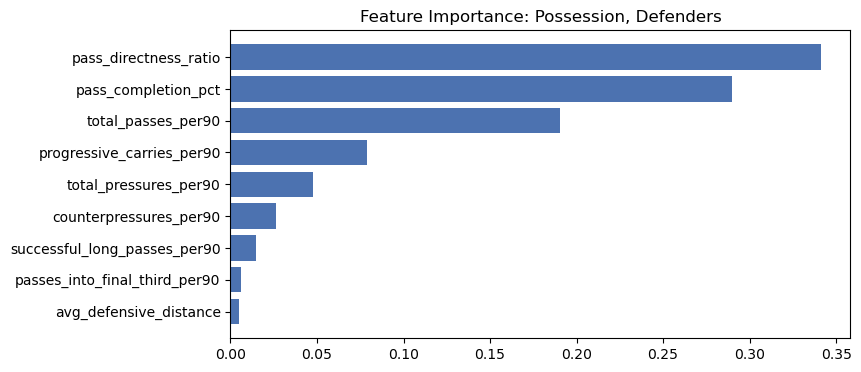

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 230}
Best Cross-Validation F1-Score: 0.603

Test data F1 Score: 0.62

              precision    recall  f1-score   support

     Not Fit       0.70      0.70      0.70        10
      Is Fit       0.62      0.62      0.62         8

    accuracy                           0.67        18
   macro avg       0.66      0.66      0.66        18
weighted avg       0.67      0.67      0.67        18



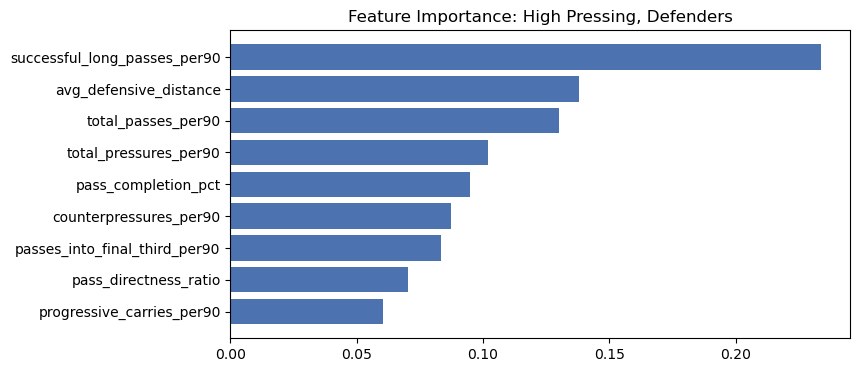

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 220}
Best Cross-Validation F1-Score: 0.788

Test data F1 Score: 0.82

              precision    recall  f1-score   support

     Not Fit       1.00      0.73      0.84        11
      Is Fit       0.70      1.00      0.82         7

    accuracy                           0.83        18
   macro avg       0.85      0.86      0.83        18
weighted avg       0.88      0.83      0.83        18



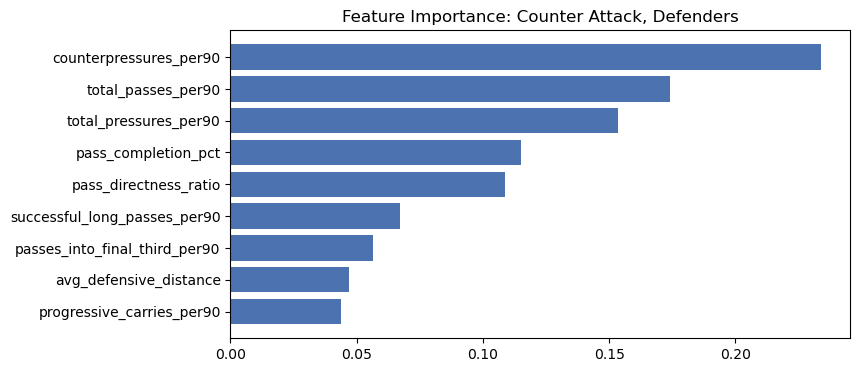

------------
MIDFIELDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'max_depth': 11, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 228}
Best Cross-Validation F1-Score: 0.898

Test data F1 Score: 0.89

              precision    recall  f1-score   support

     Not Fit       0.91      1.00      0.95        10
      Is Fit       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



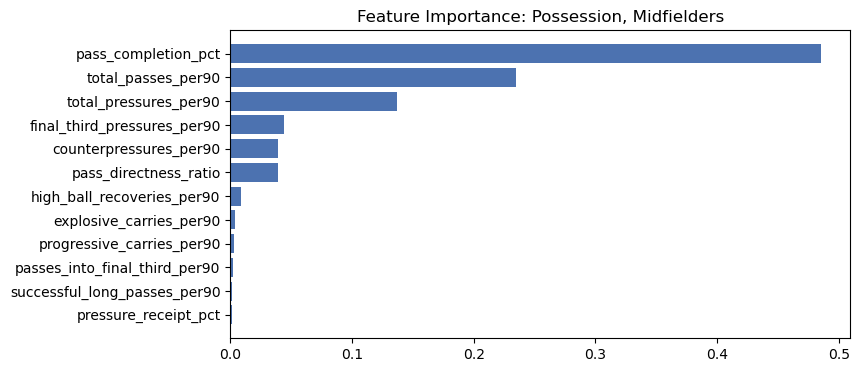

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 289}
Best Cross-Validation F1-Score: 0.657

Test data F1 Score: 0.60

              precision    recall  f1-score   support

     Not Fit       0.80      0.80      0.80        10
      Is Fit       0.60      0.60      0.60         5

    accuracy                           0.73        15
   macro avg       0.70      0.70      0.70        15
weighted avg       0.73      0.73      0.73        15



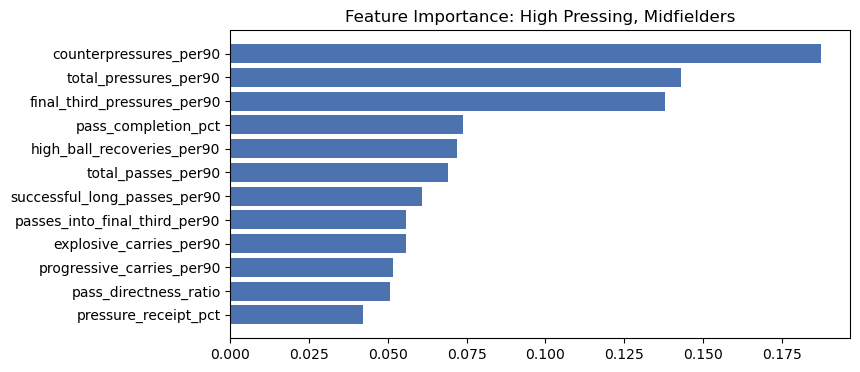

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
Best Cross-Validation F1-Score: 0.754

Test data F1 Score: 0.92

              precision    recall  f1-score   support

     Not Fit       0.89      1.00      0.94         8
      Is Fit       1.00      0.86      0.92         7

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



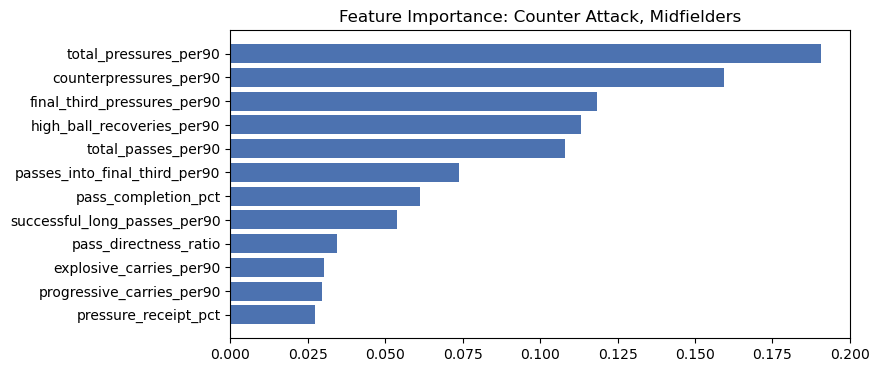

------------
ATTACKERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'max_depth': 7, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 314}
Best Cross-Validation F1-Score: 0.878

Test data F1 Score: 0.73

              precision    recall  f1-score   support

     Not Fit       0.83      0.71      0.77         7
      Is Fit       0.67      0.80      0.73         5

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12



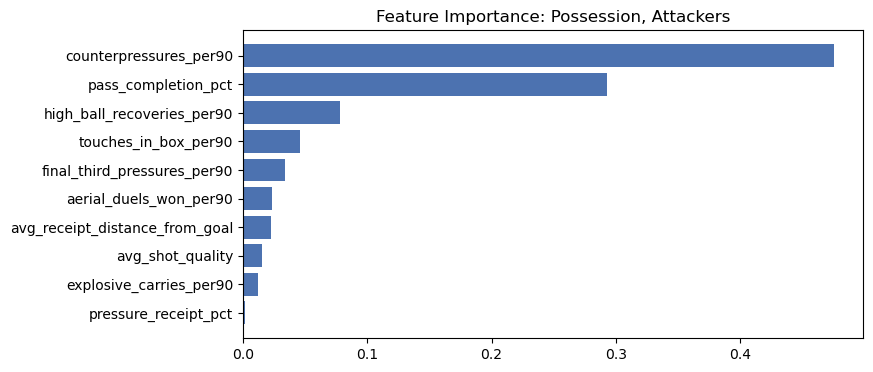

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 317}
Best Cross-Validation F1-Score: 0.574

Test data F1 Score: 0.67

              precision    recall  f1-score   support

     Not Fit       0.80      1.00      0.89         8
      Is Fit       1.00      0.50      0.67         4

    accuracy                           0.83        12
   macro avg       0.90      0.75      0.78        12
weighted avg       0.87      0.83      0.81        12



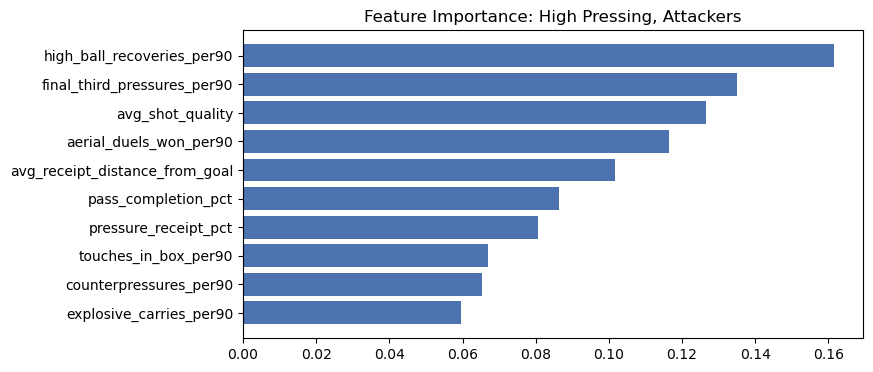

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
Best Cross-Validation F1-Score: 0.816

Test data F1 Score: 0.80

              precision    recall  f1-score   support

     Not Fit       0.86      0.86      0.86         7
      Is Fit       0.80      0.80      0.80         5

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



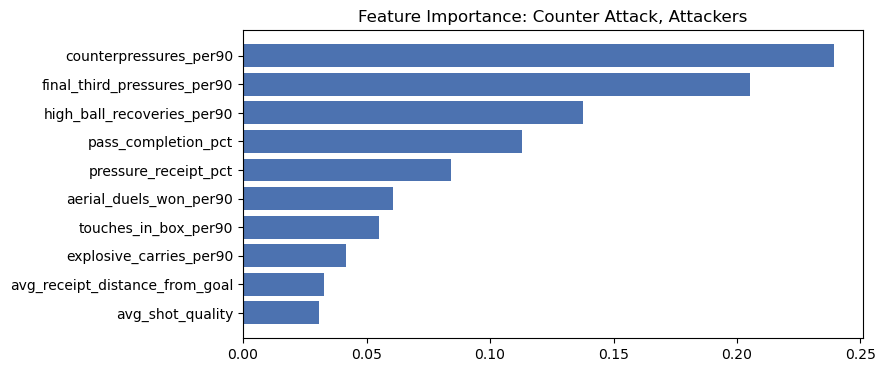

╒═════════════╤══════════════╤═════════════════╤═══════════╤═══════════╕
│             │   Possession │   High Pressing │   Counter │   Average │
╞═════════════╪══════════════╪═════════════════╪═══════════╪═══════════╡
│ Defenders   │     1        │        0.625    │  0.823529 │  0.816176 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Midfielders │     0.888889 │        0.6      │  0.923077 │  0.803989 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Attackers   │     0.727273 │        0.666667 │  0.8      │  0.731313 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Average     │     0.872054 │        0.630556 │  0.848869 │  0.783826 │
╘═════════════╧══════════════╧═════════════════╧═══════════╧═══════════╛


In [38]:
# Base Model
rf_base = RandomForestClassifier(class_weight="balanced", random_state=42)

# Hyperparameters to be tuned during randomised search
rf_param_dist = {
    "n_estimators": randint(100, 500),     # Number of trees
    "max_depth": randint(3, 12),           # Depth of trees
    "min_samples_split": randint(2, 10),   # Minimum samples to split a node
    "min_samples_leaf": randint(1, 5),     # Minimum samples at a leaf node
    "max_features": ["sqrt", "log2", None] # Number of features to consider each split
}

# Define variables to store best models in
rf_df_poss = None
rf_df_press = None
rf_df_counter = None
rf_mf_poss = None
rf_mf_press = None
rf_mf_counter = None
rf_att_poss = None
rf_att_press = None
rf_att_counter = None

# Train the model and save it
rf_df_poss, rf_df_press, rf_df_counter, rf_mf_poss, rf_mf_press, rf_mf_counter, rf_att_poss, rf_att_press, rf_att_counter = training(rf_base, rf_param_dist)

## Gradient Boosting

------------
DEFENDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'learning_rate': 0.14017769458977059, 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 393, 'subsample': 0.7002336297523043}
Best Cross-Validation F1-Score: 1.000

Test data F1 Score: 1.00

              precision    recall  f1-score   support

     Not Fit       1.00      1.00      1.00        10
      Is Fit       1.00      1.00      1.00         8

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



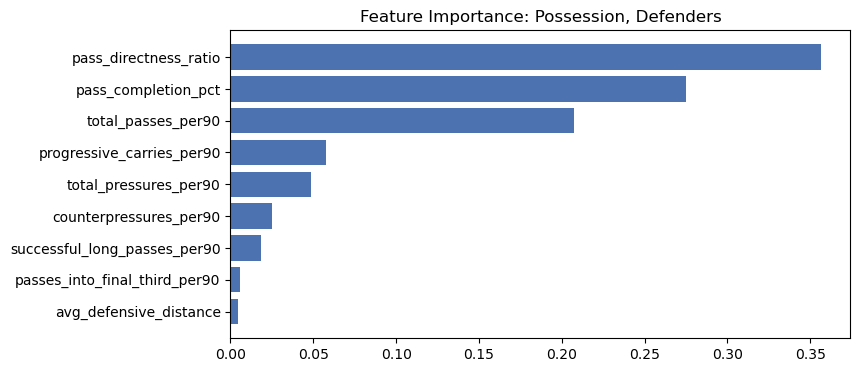

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'learning_rate': 0.1346596253655116, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 161, 'subsample': 0.7975549966080241}
Best Cross-Validation F1-Score: 0.628

Test data F1 Score: 0.62

              precision    recall  f1-score   support

     Not Fit       0.70      0.70      0.70        10
      Is Fit       0.62      0.62      0.62         8

    accuracy                           0.67        18
   macro avg       0.66      0.66      0.66        18
weighted avg       0.67      0.67      0.67        18



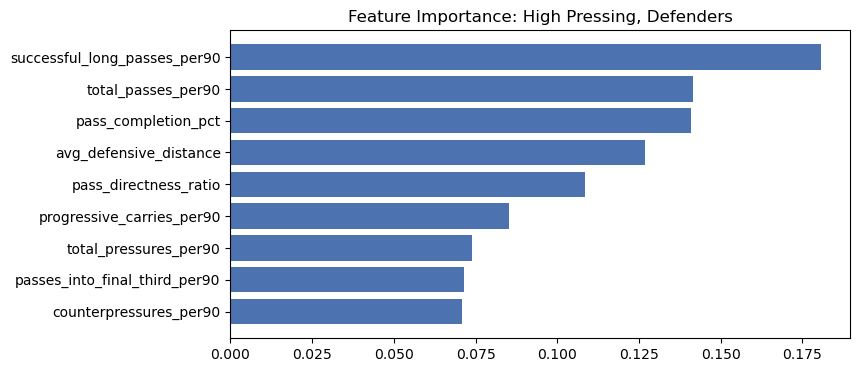

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'learning_rate': 0.20925073995158489, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 108, 'subsample': 0.7836614057776545}
Best Cross-Validation F1-Score: 0.799

Test data F1 Score: 0.67

              precision    recall  f1-score   support

     Not Fit       0.80      0.73      0.76        11
      Is Fit       0.62      0.71      0.67         7

    accuracy                           0.72        18
   macro avg       0.71      0.72      0.71        18
weighted avg       0.73      0.72      0.72        18



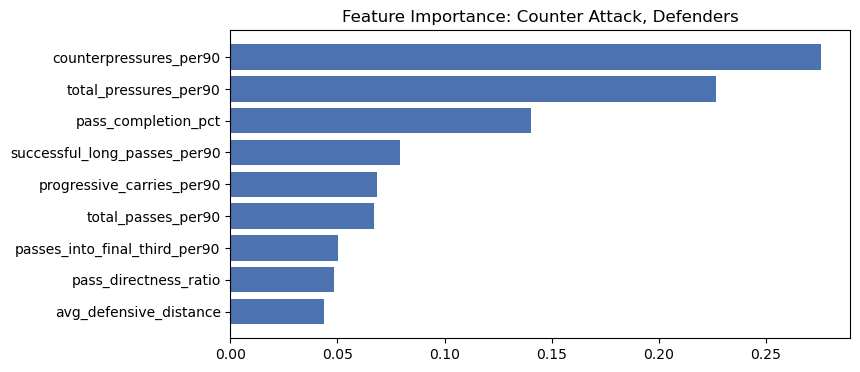

------------
MIDFIELDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'learning_rate': 0.11793842647781595, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 479, 'subsample': 0.782799754606763}
Best Cross-Validation F1-Score: 0.917

Test data F1 Score: 0.89

              precision    recall  f1-score   support

     Not Fit       0.91      1.00      0.95        10
      Is Fit       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



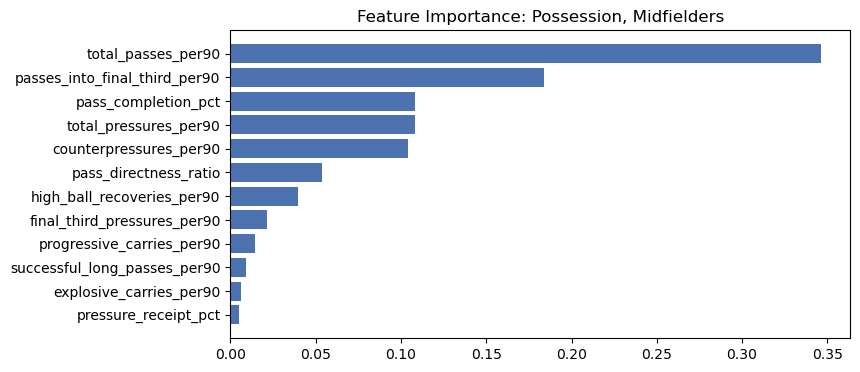

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'learning_rate': 0.11793842647781595, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 479, 'subsample': 0.782799754606763}
Best Cross-Validation F1-Score: 0.708

Test data F1 Score: 0.60

              precision    recall  f1-score   support

     Not Fit       0.80      0.80      0.80        10
      Is Fit       0.60      0.60      0.60         5

    accuracy                           0.73        15
   macro avg       0.70      0.70      0.70        15
weighted avg       0.73      0.73      0.73        15



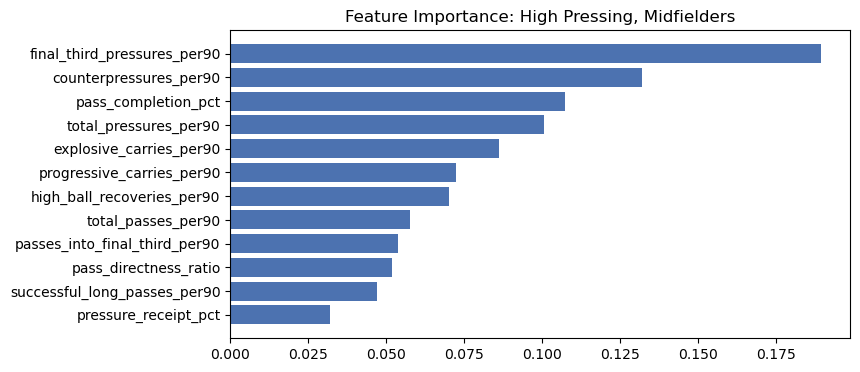

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'learning_rate': 0.029235310218284155, 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 138, 'subsample': 0.9810189966210203}
Best Cross-Validation F1-Score: 0.762

Test data F1 Score: 0.83

              precision    recall  f1-score   support

     Not Fit       0.80      1.00      0.89         8
      Is Fit       1.00      0.71      0.83         7

    accuracy                           0.87        15
   macro avg       0.90      0.86      0.86        15
weighted avg       0.89      0.87      0.86        15



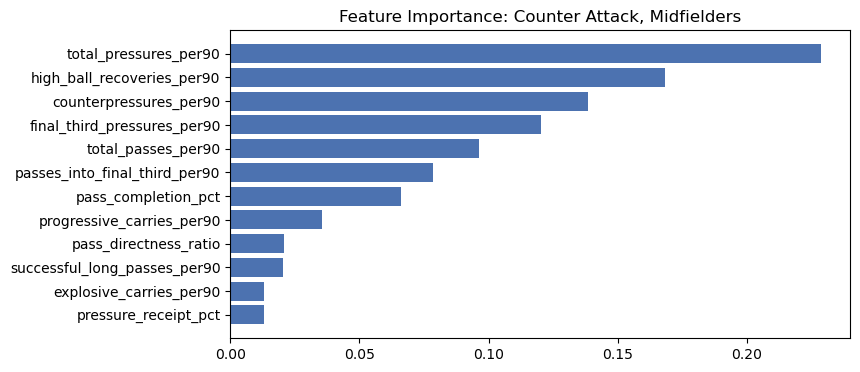

------------
ATTACKERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'learning_rate': 0.11495493205167782, 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 274, 'subsample': 0.8855158027999261}
Best Cross-Validation F1-Score: 0.897

Test data F1 Score: 0.83

              precision    recall  f1-score   support

     Not Fit       1.00      0.71      0.83         7
      Is Fit       0.71      1.00      0.83         5

    accuracy                           0.83        12
   macro avg       0.86      0.86      0.83        12
weighted avg       0.88      0.83      0.83        12



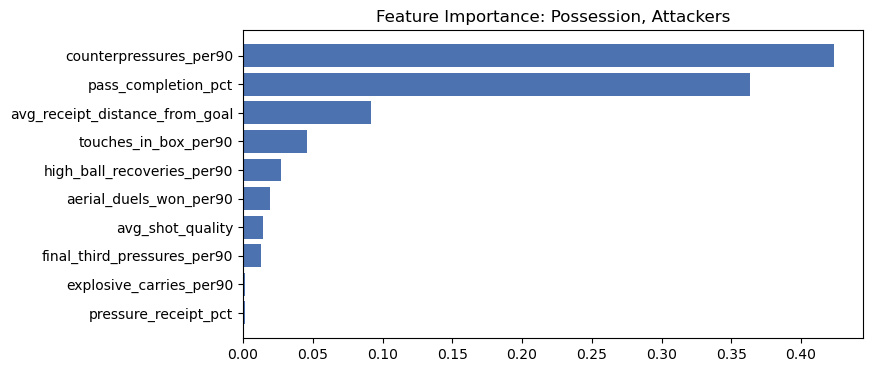

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'learning_rate': 0.14017769458977059, 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 393, 'subsample': 0.7002336297523043}
Best Cross-Validation F1-Score: 0.608

Test data F1 Score: 0.67

              precision    recall  f1-score   support

     Not Fit       0.80      1.00      0.89         8
      Is Fit       1.00      0.50      0.67         4

    accuracy                           0.83        12
   macro avg       0.90      0.75      0.78        12
weighted avg       0.87      0.83      0.81        12



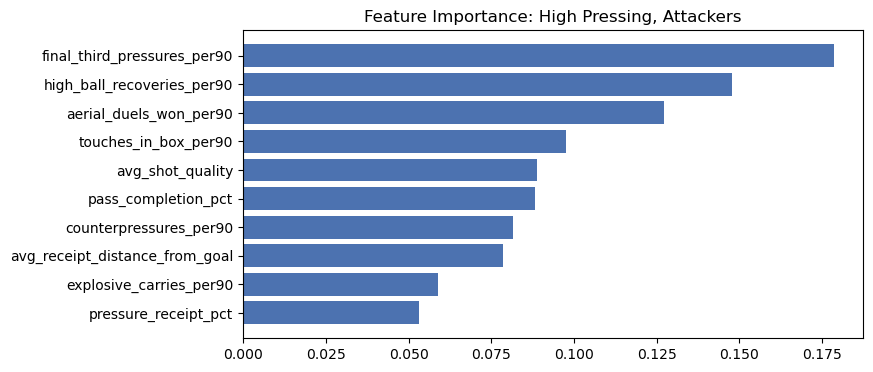

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'learning_rate': 0.14017769458977059, 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 393, 'subsample': 0.7002336297523043}
Best Cross-Validation F1-Score: 0.792

Test data F1 Score: 0.73

              precision    recall  f1-score   support

     Not Fit       0.83      0.71      0.77         7
      Is Fit       0.67      0.80      0.73         5

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12



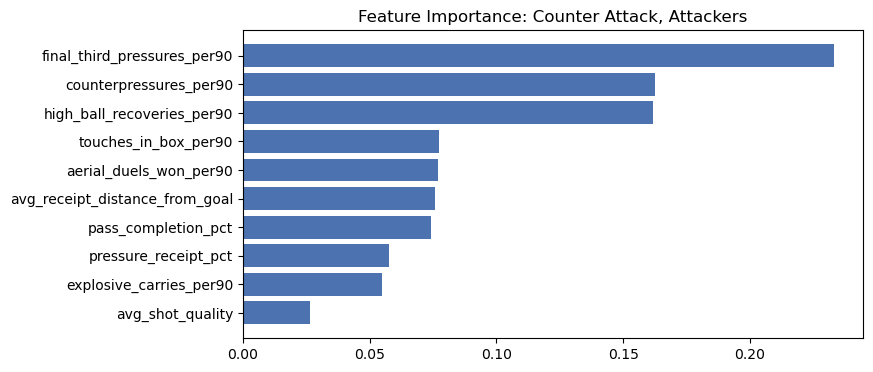

╒═════════════╤══════════════╤═════════════════╤═══════════╤═══════════╕
│             │   Possession │   High Pressing │   Counter │   Average │
╞═════════════╪══════════════╪═════════════════╪═══════════╪═══════════╡
│ Defenders   │     1        │        0.625    │  0.666667 │  0.763889 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Midfielders │     0.888889 │        0.6      │  0.833333 │  0.774074 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Attackers   │     0.833333 │        0.666667 │  0.727273 │  0.742424 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Average     │     0.907407 │        0.630556 │  0.742424 │  0.760129 │
╘═════════════╧══════════════╧═════════════════╧═══════════╧═══════════╛


In [40]:
# Base Model
gb_base = GradientBoostingClassifier(random_state=42)

# Hyperparameters to be tuned during randomised search
gb_param_dist = {
    "n_estimators": randint(100, 500),     # Number of boosting stages
    "learning_rate": uniform(0.01, 0.2),   # Step size shrinkage 
    "max_depth": randint(2, 7),            # Depth of trees
    "min_samples_split": randint(2, 10),   # Minimum samples to split a node
    "min_samples_leaf": randint(1, 5),     # Minimum samples at a leaf node
    "subsample": uniform(0.7, 0.3),        # Percentage of data used per tree
    "max_features": ["sqrt", "log2", None] # Number of features to consider each split
}

# Define variables to store best models in
gb_df_poss = None
gb_df_press = None
gb_df_counter = None
gb_mf_poss = None
gb_mf_press = None
gb_mf_counter = None
gb_att_poss = None
gb_att_press = None
gb_att_counter = None

# Train the model
gb_df_poss, gb_df_press, gb_df_counter, gb_mf_poss, gb_mf_press, gb_mf_counter, gb_att_poss, gb_att_press, gb_att_counter = training(gb_base, gb_param_dist)

## XGBoost

------------
DEFENDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.6092249700165663, 'learning_rate': 0.11495493205167782, 'max_depth': 4, 'n_estimators': 269, 'reg_alpha': 0.04666566321361543, 'reg_lambda': 3.9212665565243774, 'subsample': 0.6931085361721216}
Best Cross-Validation F1-Score: 0.986

Test data F1 Score: 1.00

              precision    recall  f1-score   support

     Not Fit       1.00      1.00      1.00        10
      Is Fit       1.00      1.00      1.00         8

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



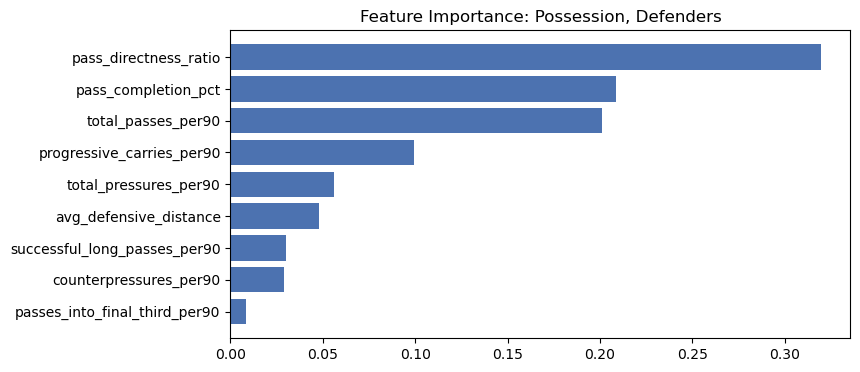

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.821105986734196, 'learning_rate': 0.12445849383416767, 'max_depth': 5, 'n_estimators': 215, 'reg_alpha': 0.2944488920695857, 'reg_lambda': 2.1552931858057756, 'subsample': 0.9404546686067428}
Best Cross-Validation F1-Score: 0.664

Test data F1 Score: 0.62

              precision    recall  f1-score   support

     Not Fit       0.70      0.70      0.70        10
      Is Fit       0.62      0.62      0.62         8

    accuracy                           0.67        18
   macro avg       0.66      0.66      0.66        18
weighted avg       0.67      0.67      0.67        18



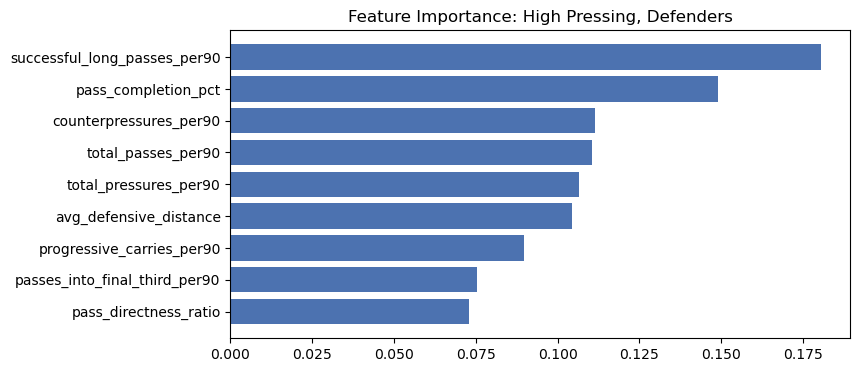

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.8270801311279966, 'learning_rate': 0.016262658491111717, 'max_depth': 3, 'n_estimators': 317, 'reg_alpha': 0.44975413336976566, 'reg_lambda': 2.185450708005443, 'subsample': 0.9706635463175177}
Best Cross-Validation F1-Score: 0.785

Test data F1 Score: 0.80

              precision    recall  f1-score   support

     Not Fit       0.90      0.82      0.86        11
      Is Fit       0.75      0.86      0.80         7

    accuracy                           0.83        18
   macro avg       0.82      0.84      0.83        18
weighted avg       0.84      0.83      0.83        18



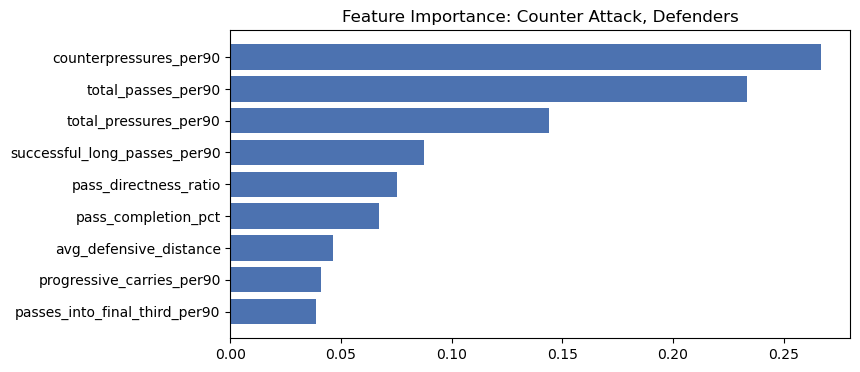

------------
MIDFIELDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.9329770563201687, 'learning_rate': 0.052467822135655234, 'max_depth': 5, 'n_estimators': 376, 'reg_alpha': 0.6174815096277165, 'reg_lambda': 2.8349594814648427, 'subsample': 0.6028265220878869}
Best Cross-Validation F1-Score: 0.900

Test data F1 Score: 0.89

              precision    recall  f1-score   support

     Not Fit       0.91      1.00      0.95        10
      Is Fit       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



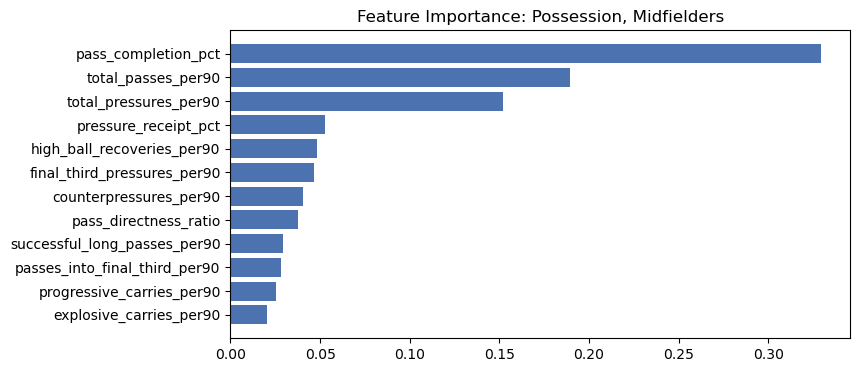

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.8989280440549523, 'learning_rate': 0.11793842647781595, 'max_depth': 5, 'n_estimators': 316, 'reg_alpha': 0.28093450968738076, 'reg_lambda': 2.6280882494747453, 'subsample': 0.6563696899899051}
Best Cross-Validation F1-Score: 0.698

Test data F1 Score: 0.83

              precision    recall  f1-score   support

     Not Fit       1.00      0.80      0.89        10
      Is Fit       0.71      1.00      0.83         5

    accuracy                           0.87        15
   macro avg       0.86      0.90      0.86        15
weighted avg       0.90      0.87      0.87        15



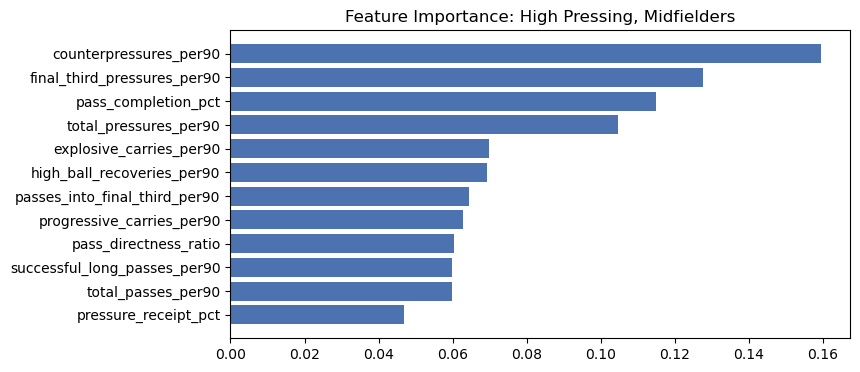

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.9624395150874216, 'learning_rate': 0.09687887310208573, 'max_depth': 2, 'n_estimators': 385, 'reg_alpha': 0.6451033620305648, 'reg_lambda': 3.0067721789892987, 'subsample': 0.9456670260287612}
Best Cross-Validation F1-Score: 0.754

Test data F1 Score: 0.83

              precision    recall  f1-score   support

     Not Fit       0.80      1.00      0.89         8
      Is Fit       1.00      0.71      0.83         7

    accuracy                           0.87        15
   macro avg       0.90      0.86      0.86        15
weighted avg       0.89      0.87      0.86        15



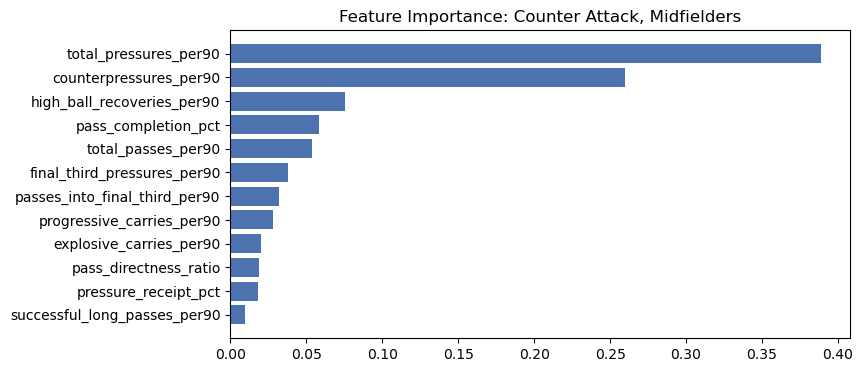

------------
ATTACKERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.9630265895704372, 'learning_rate': 0.059858445829774995, 'max_depth': 2, 'n_estimators': 242, 'reg_alpha': 0.7555511385430487, 'reg_lambda': 1.6863944964748674, 'subsample': 0.6307919639315172}
Best Cross-Validation F1-Score: 0.875

Test data F1 Score: 0.67

              precision    recall  f1-score   support

     Not Fit       0.80      0.57      0.67         7
      Is Fit       0.57      0.80      0.67         5

    accuracy                           0.67        12
   macro avg       0.69      0.69      0.67        12
weighted avg       0.70      0.67      0.67        12



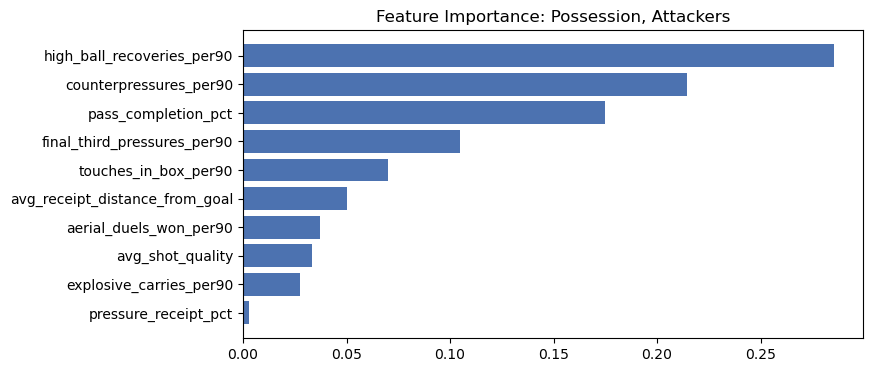

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.942529716751237, 'learning_rate': 0.09090162542443801, 'max_depth': 2, 'n_estimators': 215, 'reg_alpha': 0.08413996499504883, 'reg_lambda': 1.4848861422838413, 'subsample': 0.9594216754108317}
Best Cross-Validation F1-Score: 0.529

Test data F1 Score: 1.00

              precision    recall  f1-score   support

     Not Fit       1.00      1.00      1.00         8
      Is Fit       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



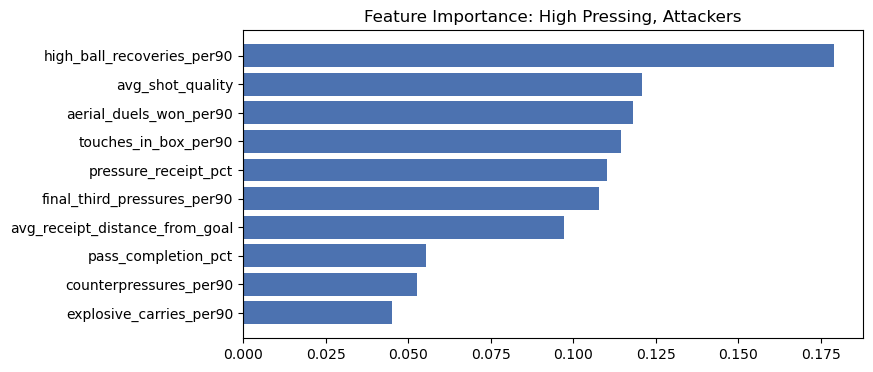

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'colsample_bytree': 0.9208787923016158, 'learning_rate': 0.024910128735954166, 'max_depth': 4, 'n_estimators': 108, 'reg_alpha': 0.7722447692966574, 'reg_lambda': 1.5961470446025172, 'subsample': 0.602208846849441}
Best Cross-Validation F1-Score: 0.776

Test data F1 Score: 0.80

              precision    recall  f1-score   support

     Not Fit       0.86      0.86      0.86         7
      Is Fit       0.80      0.80      0.80         5

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



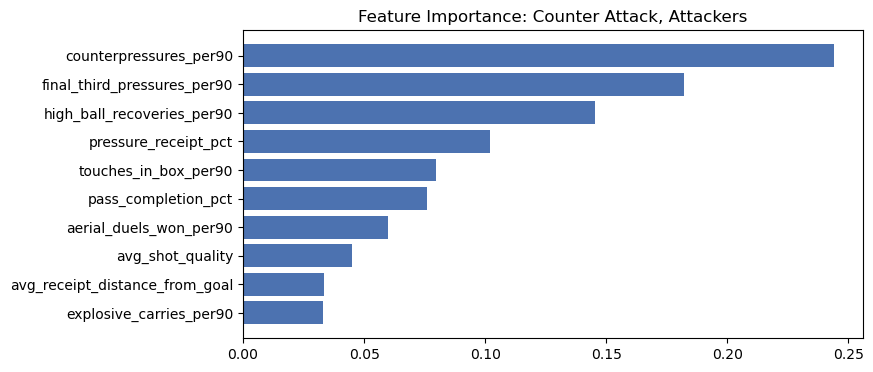

╒═════════════╤══════════════╤═════════════════╤═══════════╤═══════════╕
│             │   Possession │   High Pressing │   Counter │   Average │
╞═════════════╪══════════════╪═════════════════╪═══════════╪═══════════╡
│ Defenders   │     1        │        0.625    │  0.8      │  0.808333 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Midfielders │     0.888889 │        0.833333 │  0.833333 │  0.851852 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Attackers   │     0.666667 │        1        │  0.8      │  0.822222 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Average     │     0.851852 │        0.819444 │  0.811111 │  0.827469 │
╘═════════════╧══════════════╧═════════════════╧═══════════╧═══════════╛


In [42]:
# Base Model
xgb_base = XGBClassifier(random_state=42)

# Hyperparameters to be tuned during randomised search
xgb_param_dist = {
    "n_estimators": randint(100, 500),     # Number of boosting stages
    "learning_rate": uniform(0.01, 0.2),   # Step size shrinkage 
    "max_depth": randint(2, 6),            # Depth of trees
    "subsample": uniform(0.6, 0.4),        # Percentage of rows per tree
    "colsample_bytree": uniform(0.6, 0.4), # Percentage of columns per tree
    "reg_alpha": uniform(0, 1),            # L1 regularisation
    "reg_lambda": uniform(1, 3)            # L2 regularisation
}

# Define variables to store best models in
xgb_df_poss = None
xgb_df_press = None
xgb_df_counter = None
xgb_mf_poss = None
xgb_mf_press = None
xgb_mf_counter = None
xgb_att_poss = None
xgb_att_press = None
xgb_att_counter = None

# Train the model
xgb_df_poss, xgb_df_press, xgb_df_counter, xgb_mf_poss, xgb_mf_press, xgb_mf_counter, xgb_att_poss, xgb_att_press, xgb_att_counter = training(xgb_base, xgb_param_dist)

## Support Vector Machine

------------
DEFENDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'C': 0.2937538457632829, 'degree': 4, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.954

Test data F1 Score: 1.00

              precision    recall  f1-score   support

     Not Fit       1.00      1.00      1.00        10
      Is Fit       1.00      1.00      1.00         8

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



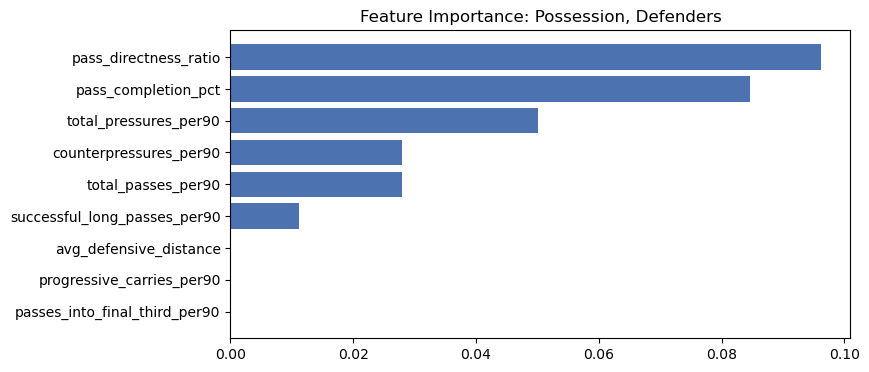

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'C': 21.830968390524596, 'degree': 2, 'gamma': 0.1, 'kernel': 'linear'}
Best Cross-Validation F1-Score: 0.650

Test data F1 Score: 0.59

              precision    recall  f1-score   support

     Not Fit       0.67      0.60      0.63        10
      Is Fit       0.56      0.62      0.59         8

    accuracy                           0.61        18
   macro avg       0.61      0.61      0.61        18
weighted avg       0.62      0.61      0.61        18



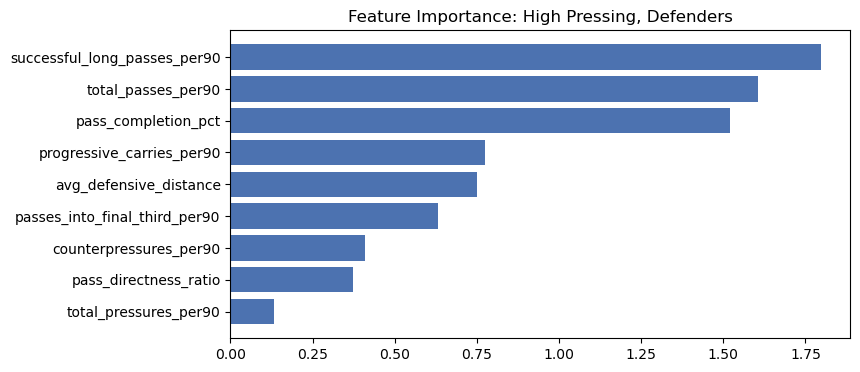

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'C': 12.271928563275042, 'degree': 4, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.839

Test data F1 Score: 0.67

              precision    recall  f1-score   support

     Not Fit       0.80      0.73      0.76        11
      Is Fit       0.62      0.71      0.67         7

    accuracy                           0.72        18
   macro avg       0.71      0.72      0.71        18
weighted avg       0.73      0.72      0.72        18



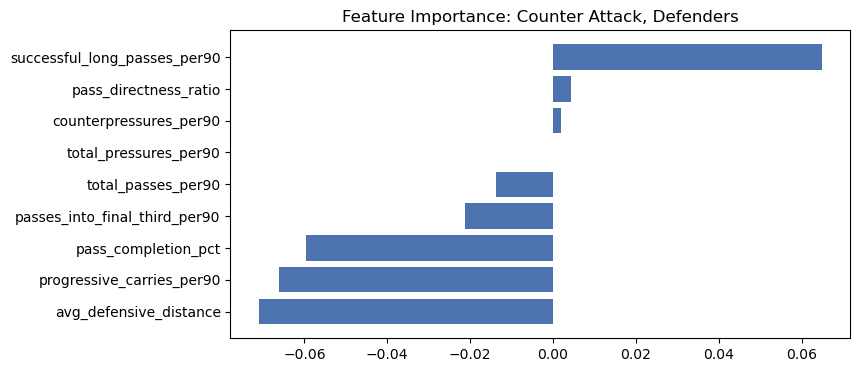

------------
MIDFIELDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'C': 21.830968390524596, 'degree': 2, 'gamma': 0.1, 'kernel': 'linear'}
Best Cross-Validation F1-Score: 0.961

Test data F1 Score: 0.89

              precision    recall  f1-score   support

     Not Fit       0.91      1.00      0.95        10
      Is Fit       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



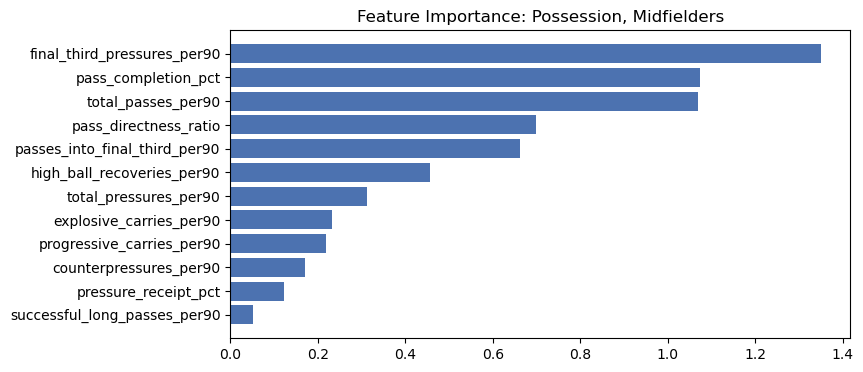

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'C': 0.45320287757648714, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.659

Test data F1 Score: 0.67

              precision    recall  f1-score   support

     Not Fit       0.82      0.90      0.86        10
      Is Fit       0.75      0.60      0.67         5

    accuracy                           0.80        15
   macro avg       0.78      0.75      0.76        15
weighted avg       0.80      0.80      0.79        15



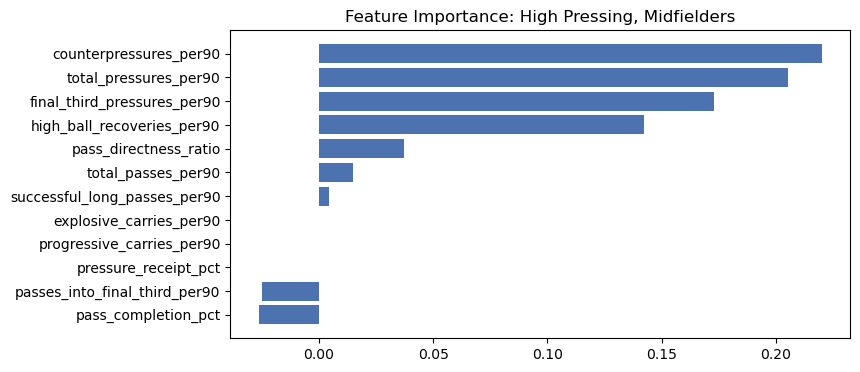

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'C': 0.45320287757648714, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.782

Test data F1 Score: 0.88

              precision    recall  f1-score   support

     Not Fit       1.00      0.75      0.86         8
      Is Fit       0.78      1.00      0.88         7

    accuracy                           0.87        15
   macro avg       0.89      0.88      0.87        15
weighted avg       0.90      0.87      0.87        15



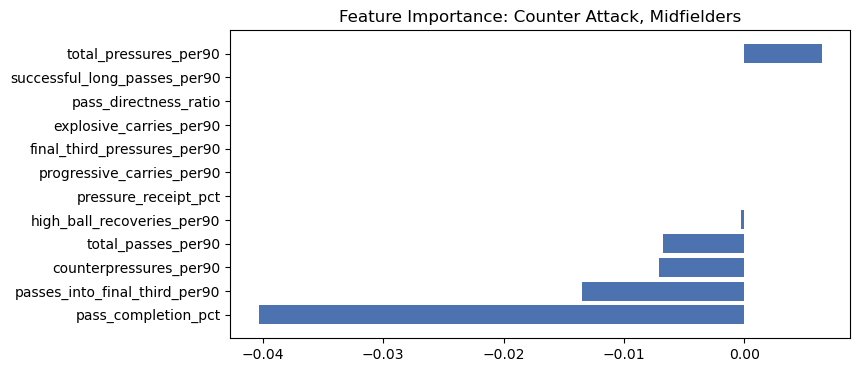

------------
ATTACKERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'C': 0.3511356313970407, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation F1-Score: 0.895

Test data F1 Score: 0.83

              precision    recall  f1-score   support

     Not Fit       1.00      0.71      0.83         7
      Is Fit       0.71      1.00      0.83         5

    accuracy                           0.83        12
   macro avg       0.86      0.86      0.83        12
weighted avg       0.88      0.83      0.83        12



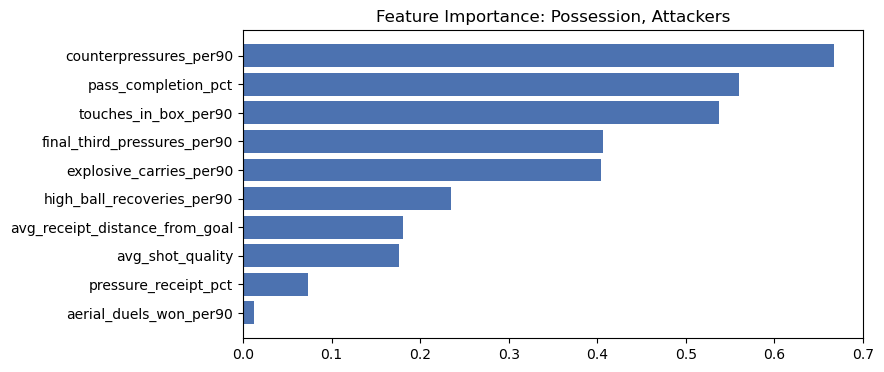

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'C': 1.5326772391384107, 'degree': 3, 'gamma': 0.1, 'kernel': 'poly'}
Best Cross-Validation F1-Score: 0.670

Test data F1 Score: 0.67

              precision    recall  f1-score   support

     Not Fit       0.80      1.00      0.89         8
      Is Fit       1.00      0.50      0.67         4

    accuracy                           0.83        12
   macro avg       0.90      0.75      0.78        12
weighted avg       0.87      0.83      0.81        12



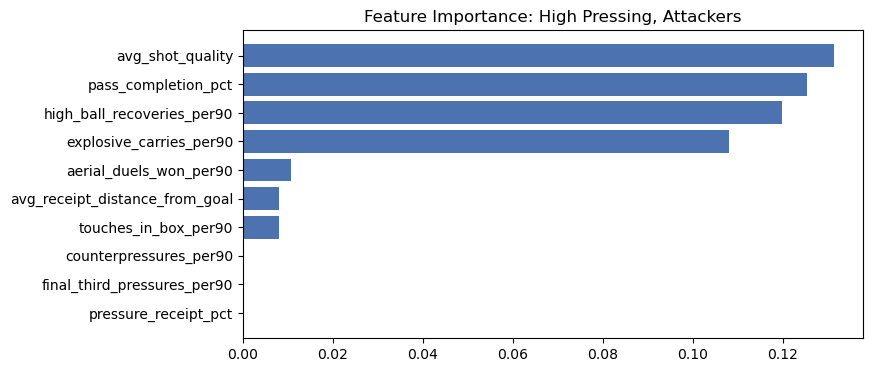

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'C': 1.4040609919104425, 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.869

Test data F1 Score: 0.80

              precision    recall  f1-score   support

     Not Fit       0.86      0.86      0.86         7
      Is Fit       0.80      0.80      0.80         5

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



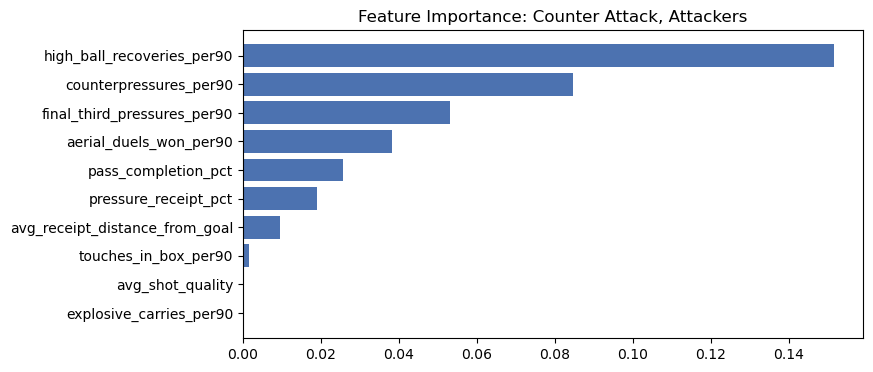

╒═════════════╤══════════════╤═════════════════╤═══════════╤═══════════╕
│             │   Possession │   High Pressing │   Counter │   Average │
╞═════════════╪══════════════╪═════════════════╪═══════════╪═══════════╡
│ Defenders   │     1        │        0.588235 │  0.666667 │  0.751634 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Midfielders │     0.888889 │        0.666667 │  0.875    │  0.810185 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Attackers   │     0.833333 │        0.666667 │  0.8      │  0.766667 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Average     │     0.907407 │        0.640523 │  0.780556 │  0.776162 │
╘═════════════╧══════════════╧═════════════════╧═══════════╧═══════════╛


In [44]:
# Base Model
svm_base = SVC(class_weight="balanced", probability=True, random_state=42)

# Hyperparameters to be tuned during randomised search
svm_param_dist = {
    "C": loguniform(0.1, 100),             # Controls regularisation
    "kernel": ["rbf", "linear", "poly"],   # Mathematical function
    "gamma": ["scale", "auto", 0.1, 0.01], # How tightly model wraps around training data
    "degree": randint(2, 5)                # For poly kernel
    }

# Define variables to store best models in
svm_df_poss = None
svm_df_press = None
svm_df_counter = None
svm_mf_poss = None
svm_mf_press = None
svm_mf_counter = None
svm_att_poss = None
svm_att_press = None
svm_att_counter = None

# Train the model
svm_df_poss, svm_df_press, svm_df_counter, svm_mf_poss, svm_mf_press, svm_mf_counter, svm_att_poss, svm_att_press, svm_att_counter = training(svm_base, svm_param_dist)

## Logistic Regression

------------
DEFENDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'C': 0.8200518402245829, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.984

Test data F1 Score: 1.00

              precision    recall  f1-score   support

     Not Fit       1.00      1.00      1.00        10
      Is Fit       1.00      1.00      1.00         8

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



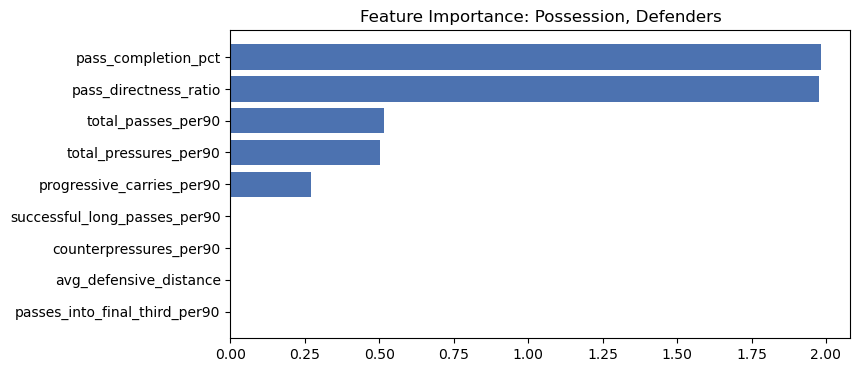

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'C': 0.10053940194693017, 'penalty': 'l2', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.657

Test data F1 Score: 0.53

              precision    recall  f1-score   support

     Not Fit       0.64      0.70      0.67        10
      Is Fit       0.57      0.50      0.53         8

    accuracy                           0.61        18
   macro avg       0.60      0.60      0.60        18
weighted avg       0.61      0.61      0.61        18



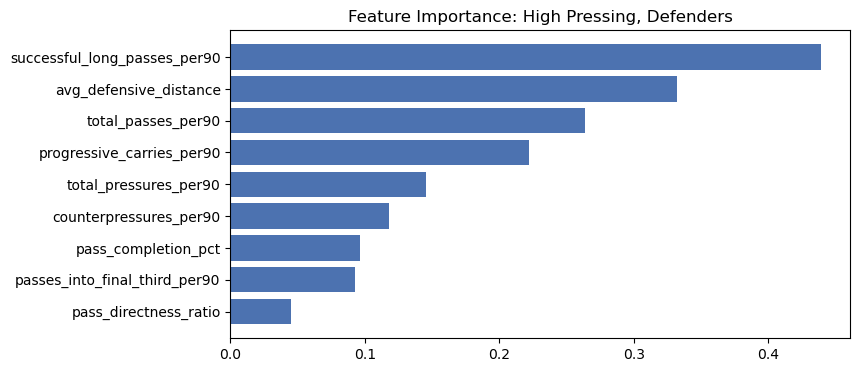

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'C': 7.164040428191009, 'penalty': 'l2', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.858

Test data F1 Score: 0.71

              precision    recall  f1-score   support

     Not Fit       0.88      0.64      0.74        11
      Is Fit       0.60      0.86      0.71         7

    accuracy                           0.72        18
   macro avg       0.74      0.75      0.72        18
weighted avg       0.77      0.72      0.72        18



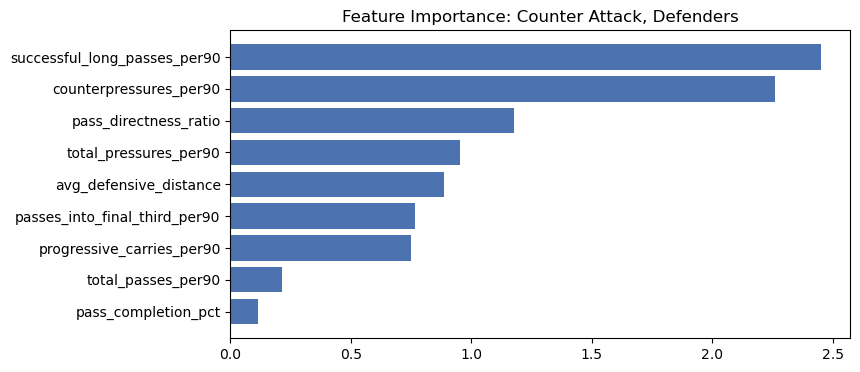

------------
MIDFIELDERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'C': 0.355062142707077, 'penalty': 'l2', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.961

Test data F1 Score: 0.89

              precision    recall  f1-score   support

     Not Fit       0.91      1.00      0.95        10
      Is Fit       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



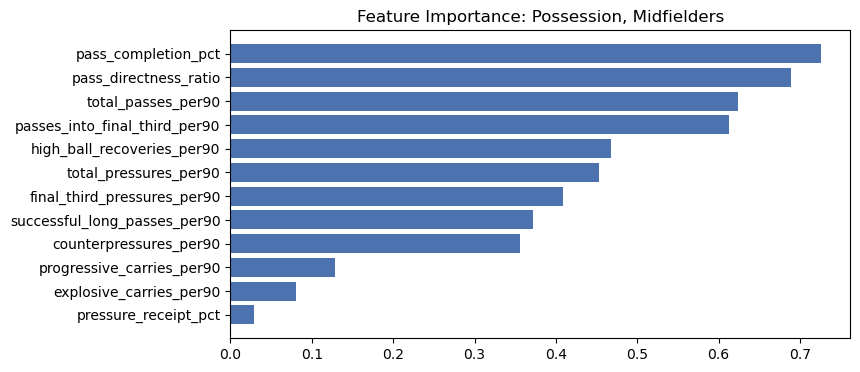

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'C': 1.0025956902289566, 'penalty': 'l2', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.662

Test data F1 Score: 0.83

              precision    recall  f1-score   support

     Not Fit       1.00      0.80      0.89        10
      Is Fit       0.71      1.00      0.83         5

    accuracy                           0.87        15
   macro avg       0.86      0.90      0.86        15
weighted avg       0.90      0.87      0.87        15



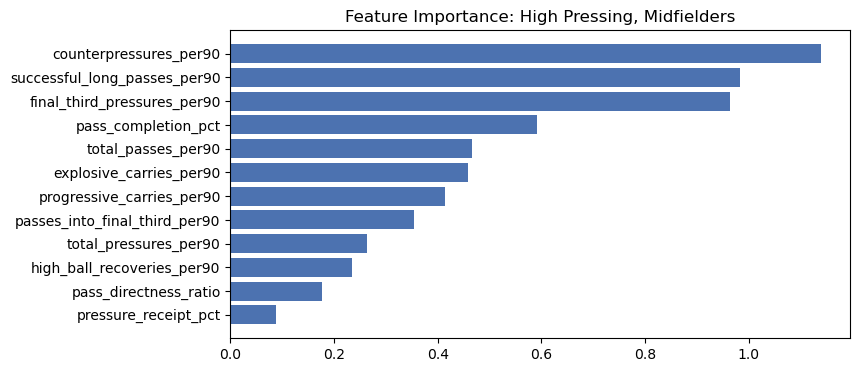

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'C': 0.10388823104027935, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.799

Test data F1 Score: 0.86

              precision    recall  f1-score   support

     Not Fit       0.88      0.88      0.88         8
      Is Fit       0.86      0.86      0.86         7

    accuracy                           0.87        15
   macro avg       0.87      0.87      0.87        15
weighted avg       0.87      0.87      0.87        15



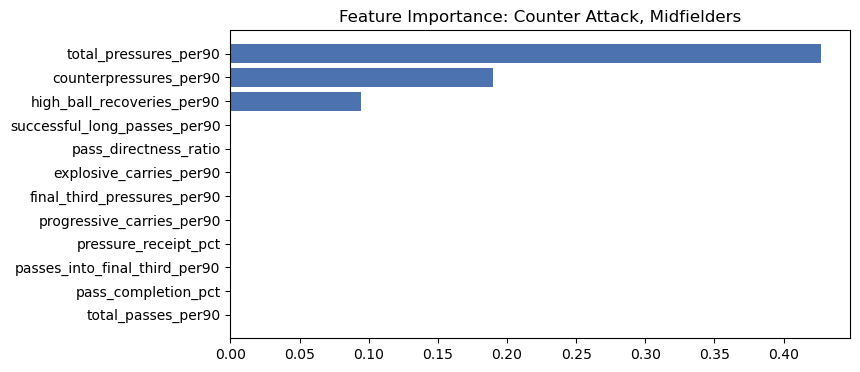

------------
ATTACKERS
------------
MODEL FIT FOR POSSESSION

Random Search running!
Best Parameters Found:{'C': 2.175195311877764, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.875

Test data F1 Score: 0.83

              precision    recall  f1-score   support

     Not Fit       1.00      0.71      0.83         7
      Is Fit       0.71      1.00      0.83         5

    accuracy                           0.83        12
   macro avg       0.86      0.86      0.83        12
weighted avg       0.88      0.83      0.83        12



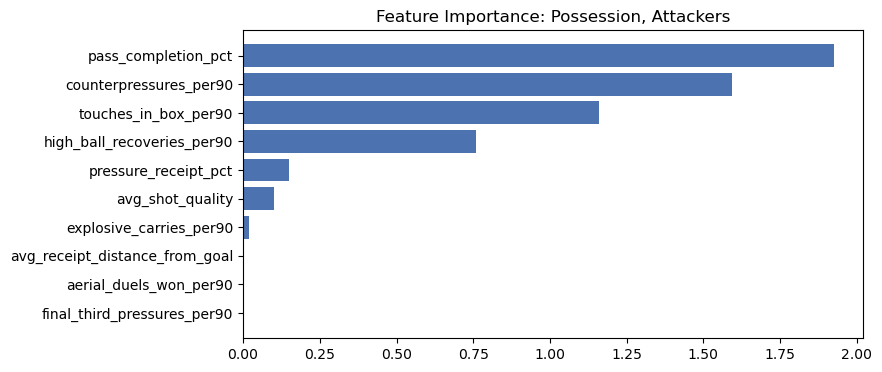

MODEL FIT FOR HIGH PRESSING

Random Search running!
Best Parameters Found:{'C': 0.3872118032174582, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.590

Test data F1 Score: 0.57

              precision    recall  f1-score   support

     Not Fit       0.78      0.88      0.82         8
      Is Fit       0.67      0.50      0.57         4

    accuracy                           0.75        12
   macro avg       0.72      0.69      0.70        12
weighted avg       0.74      0.75      0.74        12



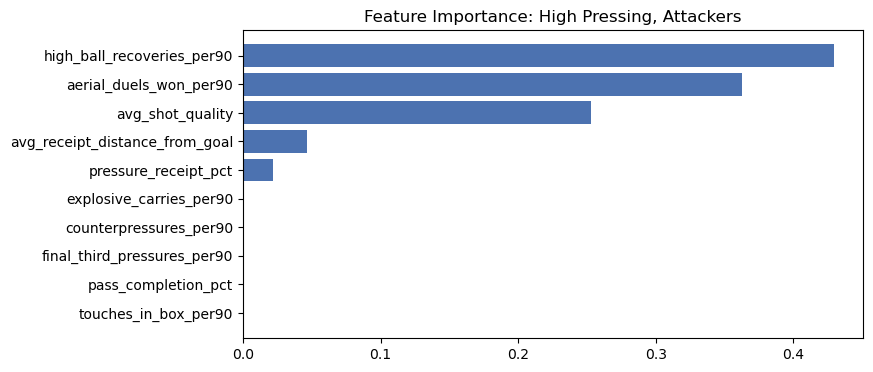

MODEL FIT FOR COUNTER ATTACK

Random Search running!
Best Parameters Found:{'C': 1.3292918943162166, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validation F1-Score: 0.844

Test data F1 Score: 0.80

              precision    recall  f1-score   support

     Not Fit       0.86      0.86      0.86         7
      Is Fit       0.80      0.80      0.80         5

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



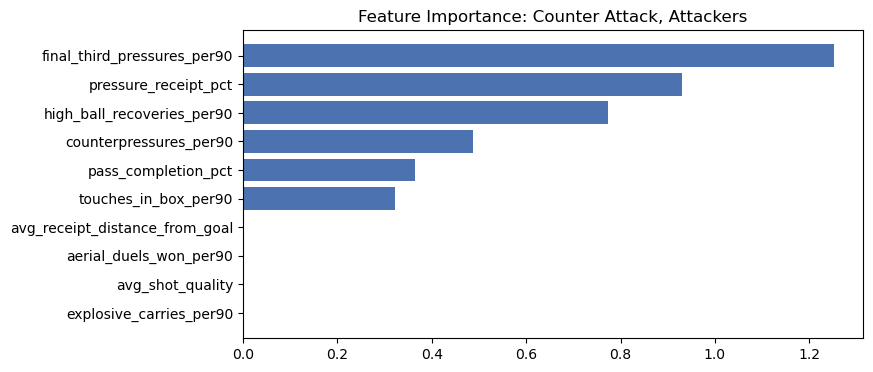

╒═════════════╤══════════════╤═════════════════╤═══════════╤═══════════╕
│             │   Possession │   High Pressing │   Counter │   Average │
╞═════════════╪══════════════╪═════════════════╪═══════════╪═══════════╡
│ Defenders   │     1        │        0.533333 │  0.705882 │  0.746405 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Midfielders │     0.888889 │        0.833333 │  0.857143 │  0.859788 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Attackers   │     0.833333 │        0.571429 │  0.8      │  0.734921 │
├─────────────┼──────────────┼─────────────────┼───────────┼───────────┤
│ Average     │     0.907407 │        0.646032 │  0.787675 │  0.780371 │
╘═════════════╧══════════════╧═════════════════╧═══════════╧═══════════╛


In [46]:
# Base Model
lr_base = LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42)

# Hyperparameters to be tuned during randomised search
lr_param_dist = {
    "C": loguniform(0.1, 100), # Controls regularisation
    "penalty": ["l1", "l2"],   # What is done with useless stats
    "solver": ["saga"]         # The only one that supports l1 and l2 efficiently
}

# Define variables to store best models in
lr_df_poss = None
lr_df_press = None
lr_df_counter = None
lr_mf_poss = None
lr_mf_press = None
lr_mf_counter = None
lr_att_poss = None
lr_att_press = None
lr_att_counter = None


# Train the model
lr_df_poss, lr_df_press, lr_df_counter, lr_mf_poss, lr_mf_press, lr_mf_counter, lr_att_poss, lr_att_press, lr_att_counter = training(lr_base, lr_param_dist)

# Export Models

In [48]:
# Create "master scalers" to export

# 1. Isolate the data for each position
defenders_df = df[df["position_group"] == "Defender"]
midfielders_df = df[df["position_group"] == "Midfielder"]
attackers_df = df[df["position_group"] == "Attacker"]

# 2. Fit a Master Scaler for each position using their specific feature lists!
def_scaler = StandardScaler().fit(defenders_df[defender_features])
mid_scaler = StandardScaler().fit(midfielders_df[midfielder_features])
att_scaler = StandardScaler().fit(attackers_df[attacker_features])

# 3. Package them into a dictionary
saved_scalers = {
    "Defender": def_scaler,
    "Midfielder": mid_scaler,
    "Attacker": att_scaler
}

# 4. Save the dictionary to your hard drive
joblib.dump(saved_scalers, SCALER_PATH / "tactical_scalers.pkl")
print("Positional Scalers successfully saved!")

Positional Scalers successfully saved!


In [49]:
# Save the best model for each position and style
saved_models = {
    "Defender": {
        "Possession": svm_df_poss,
        "High Pressing": svm_df_press,
        "Counter Attack": svm_df_counter
    },
    "Midfielder": {
        "Possession": svm_mf_poss,
        "High Pressing": svm_mf_press,
        "Counter Attack": svm_mf_counter
    },
    "Attacker": {
        "Possession": rf_att_poss,
        "High Pressing": rf_att_press,
        "Counter Attack": rf_att_counter
    }
}

joblib.dump(saved_models, MODEL_PATH / "scouting_models.pkl")
print("Models successfully saved")

Models successfully saved
